In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scanpy as sc
from umap import UMAP

/Users/nveshaan/Developer/msde/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
file = h5py.File("/Volumes/SSD/data/hlca_50pc_50k.hdf5", 'r')
file2 = h5py.File("/Volumes/SSD/data/hlca_50pc_50k_50t.hdf5", 'r')
adata = sc.read_h5ad('/Volumes/SSD/data/hlca.h5ad', backed='r')

In [5]:
labels, colors = np.unique(adata.obs["cell_type"], return_inverse=True)

In [6]:
idx = np.where(colors != 49)

In [7]:
umap = UMAP()
umap.fit(file["trajectory"]["0"])

,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


In [9]:
og = umap.transform(file["trajectory"]["0"][idx])
nn = umap.transform(file["trajectory"]["20"][idx])
ann = umap.transform(file2["trajectory"]["20"][idx])

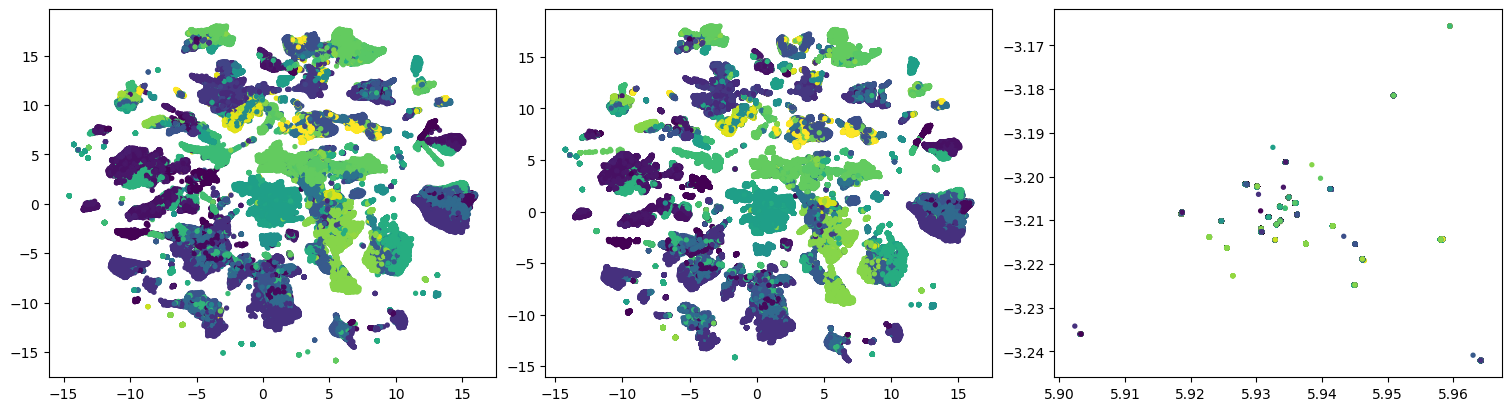

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')

axes[0].scatter(og[:, 0], og[:, 1], c=colors[idx], s=8)
axes[1].scatter(nn[:, 0], nn[:, 1], c=colors[idx], s=8)
axes[2].scatter(ann[:, 0], ann[:, 1], c=colors[idx], s=8)

plt.show()

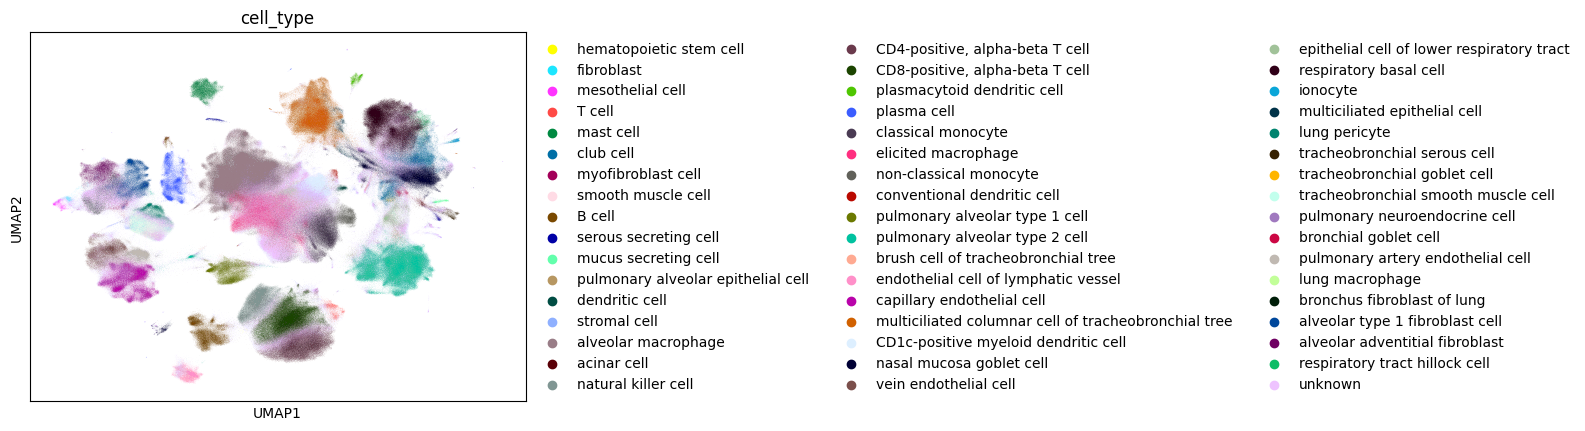

In [22]:
sc.pl.umap(adata, color="cell_type")

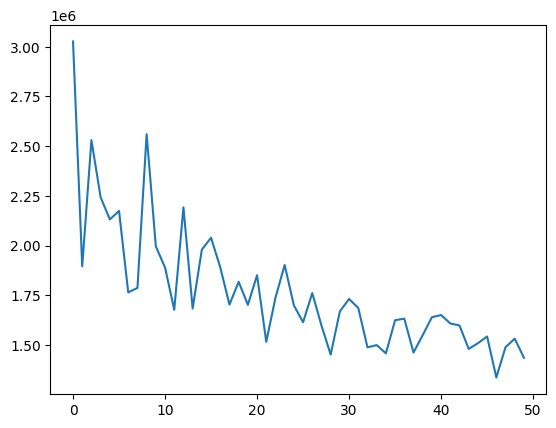

In [17]:
plt.plot(file["feature_dist"][()])
plt.show()